<a href="https://www.kaggle.com/code/vibhojoshi/complete-solution?scriptVersionId=271877718" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [17]:
# -------------------------------------------------
# 0. Imports & Setup
# -------------------------------------------------
import pandas as pd
import numpy as np
import warnings, gc, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------------------------------
# 1. Load Data
# -------------------------------------------------
DATA = '/kaggle/input/playground-series-s5e10'
train = pd.read_csv(f'{DATA}/train.csv')
test  = pd.read_csv(f'{DATA}/test.csv')
sub   = pd.read_csv(f'{DATA}/sample_submission.csv')

print(train.shape, test.shape)

(517754, 14) (172585, 13)


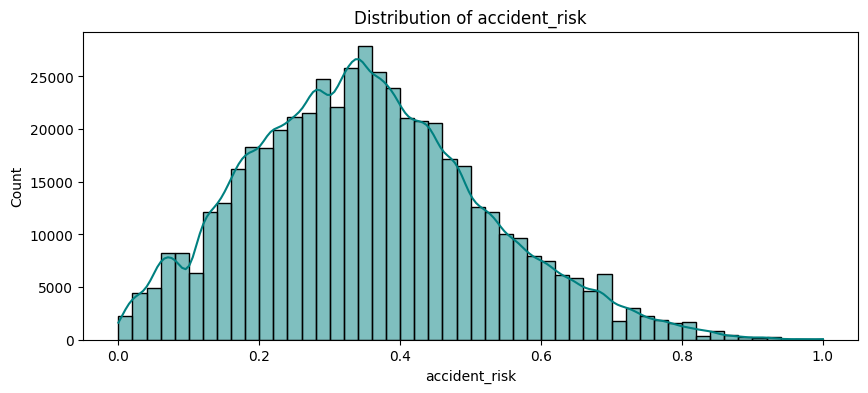

count    517754.000000
mean          0.352377
std           0.166417
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
target = 'accident_risk'

plt.figure(figsize=(10,4))
sns.histplot(train[target], kde=True, bins=50, color='teal')
plt.title('Distribution of accident_risk')
plt.xlabel('accident_risk')
plt.show()

print(train[target].describe())

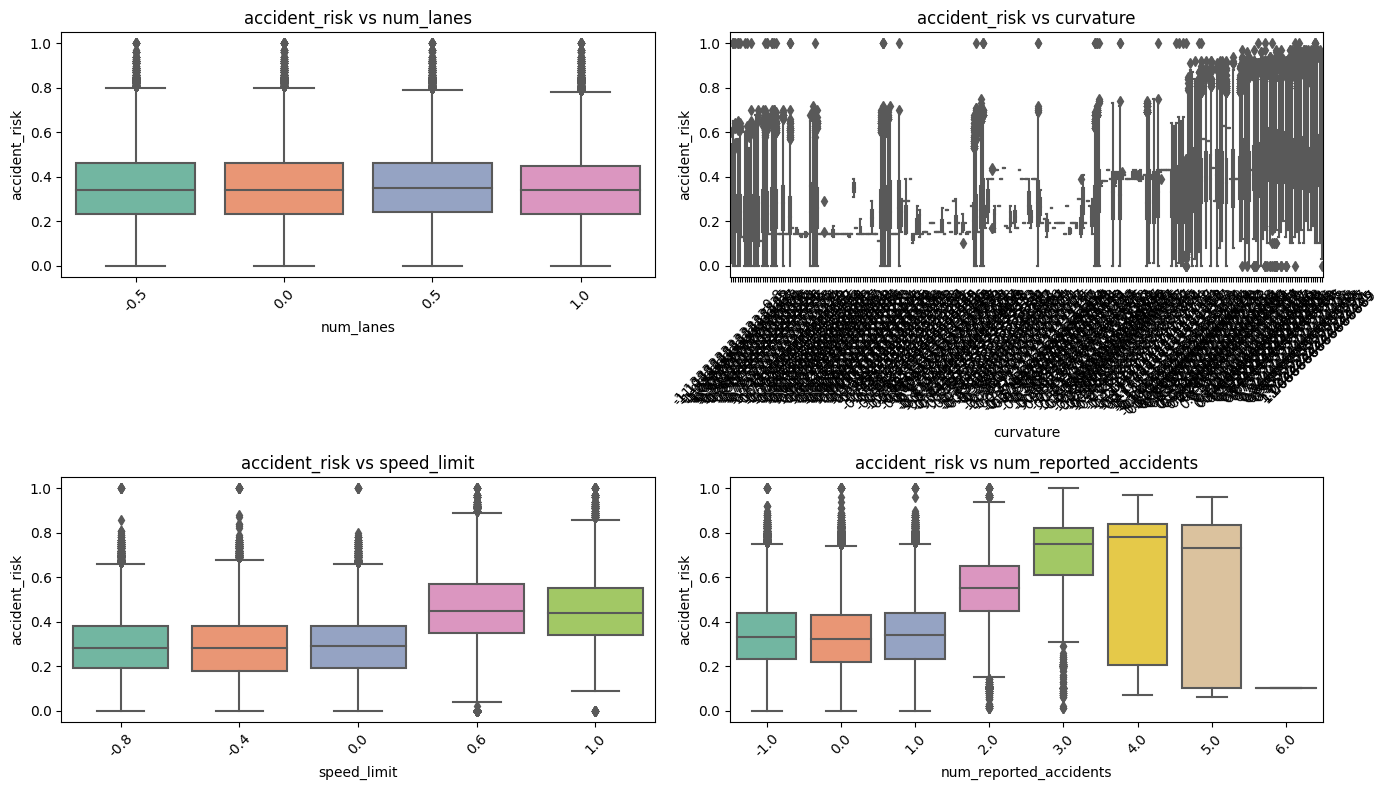

In [20]:
cat_cols = [
    'road_type', 'lighting', 'weather',
    'road_signs_present', 'public_road',
    'time_of_day', 'holiday', 'school_season'
]
num_cols = ['num_lanes','curvature','speed_limit','num_reported_accidents']

n_cols = 2
n_rows = (len(num_cols)) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x=col, y=target, ax=axes[i], palette='Set2')
    axes[i].set_title(f'accident_risk vs {col}')
    axes[i].tick_params(axis='x', rotation=45)

# hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

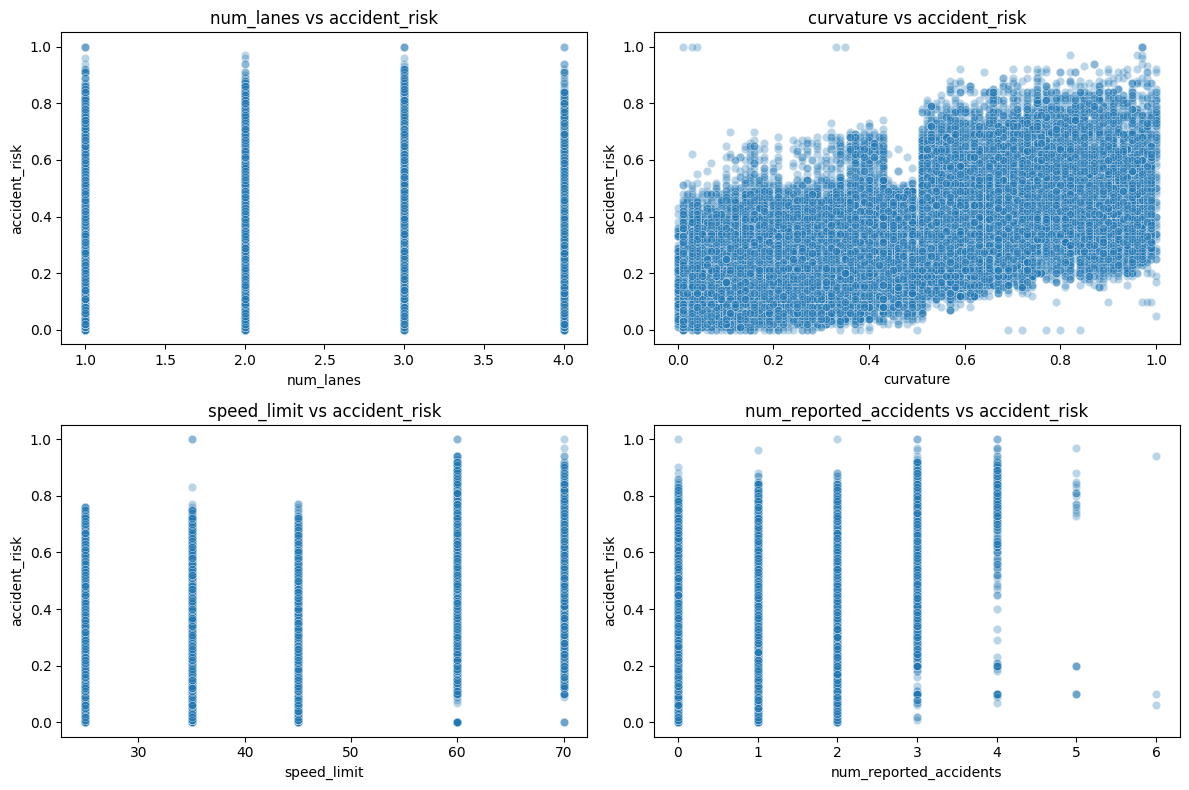

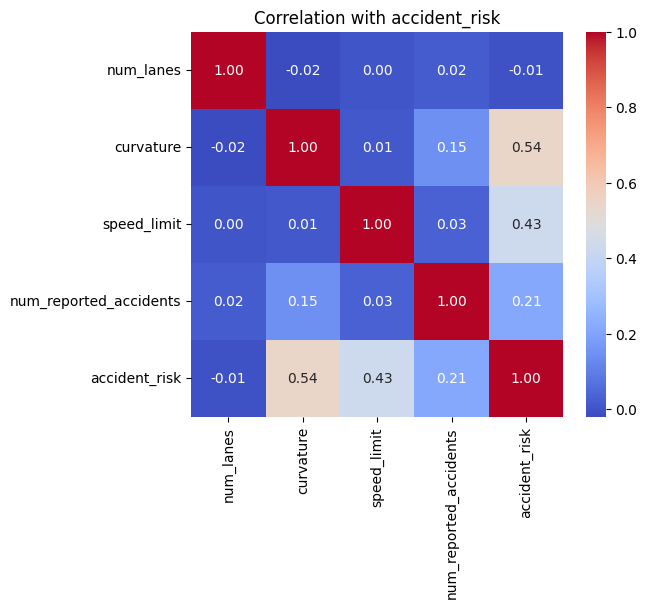

In [6]:
num_cols = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2,2,i)
    sns.scatterplot(data=train.sample(frac=0.1), x=col, y=target, alpha=0.3)
    plt.title(f'{col} vs accident_risk')
plt.tight_layout()
plt.show()

# Correlation matrix
corr = train[num_cols + [target]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with accident_risk')
plt.show()

In [7]:
summary = train.groupby(cat_cols)[target].median().reset_index()
summary = summary.sort_values(target, ascending=False)
print(summary.head(10))

     road_type lighting weather  road_signs_present  public_road time_of_day  \
806      rural    night   foggy                True         True   afternoon   
783      rural    night   foggy               False         True   afternoon   
811      rural    night   foggy                True         True     evening   
814      rural    night   foggy                True         True     morning   
815      rural    night   foggy                True         True     morning   
1222     urban    night   foggy               False         True     morning   
383    highway    night   foggy                True         True     morning   
1239     urban    night   foggy                True         True   afternoon   
790      rural    night   foggy               False         True     morning   
375    highway    night   foggy                True         True   afternoon   

      holiday  school_season  accident_risk  
806      True          False           0.54  
783      True           Tru

In [19]:
# Categorical & Numeric
cat_cols = ['road_type','lighting','weather','road_signs_present','public_road',
            'time_of_day','holiday','school_season']
num_cols = ['num_lanes','curvature','speed_limit','num_reported_accidents']

target = 'accident_risk'

# One-Hot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_ohe = pd.DataFrame(ohe.fit_transform(train[cat_cols]), 
                         columns=ohe.get_feature_names_out(cat_cols), index=train.index)
test_ohe  = pd.DataFrame(ohe.transform(test[cat_cols]), 
                         columns=ohe.get_feature_names_out(cat_cols), index=test.index)

# Drop original cat cols
train = pd.concat([train.drop(cat_cols, axis=1), train_ohe], axis=1)
test  = pd.concat([test.drop(cat_cols, axis=1), test_ohe], axis=1)

# Interaction features
train['curv_speed'] = train['curvature'] * train['speed_limit']
train['lanes_speed'] = train['num_lanes'] * train['speed_limit']
train['accidents_curv'] = train['num_reported_accidents'] * train['curvature']

test['curv_speed'] = test['curvature'] * test['speed_limit']
test['lanes_speed'] = test['num_lanes'] * test['speed_limit']
test['accidents_curv'] = test['num_reported_accidents'] * test['curvature']

# Update num_cols
num_cols += ['curv_speed', 'lanes_speed', 'accidents_curv']

# Robust Scaling (better for outliers)
scaler = RobustScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols]  = scaler.transform(test[num_cols])

In [21]:
feature_cols = num_cols + list(ohe.get_feature_names_out(cat_cols))
X = train[feature_cols]
y = train[target]
X_test = test[feature_cols]

print(f"Features: {len(feature_cols)}")

Features: 24


In [22]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Store OOF & test predictions
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

rmse_lgb, rmse_xgb, rmse_cat = [], [], []

SEED = 42

In [23]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 128,
    'max_depth': 10,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.75,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_child_samples': 20,
    'verbose': -1,
    'seed': SEED
}

for fold, (idx_tr, idx_val) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

    model = lgb.LGBMRegressor(**lgb_params, n_estimators=5000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )
    val_pred = model.predict(X_val)
    oof_lgb[idx_val] = val_pred
    rmse = mean_squared_error(y_val, val_pred, squared=False)
    rmse_lgb.append(rmse)
    print(f'LGB Fold {fold} RMSE: {rmse:.6f} | Best: {model.best_iteration_}')
    test_lgb += model.predict(X_test) / n_splits

print(f'LGB CV: {np.mean(rmse_lgb):.6f} ± {np.std(rmse_lgb):.6f}')

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[449]	valid_0's rmse: 0.0561953
LGB Fold 1 RMSE: 0.056195 | Best: 449
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[405]	valid_0's rmse: 0.0560761
LGB Fold 2 RMSE: 0.056076 | Best: 405
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[379]	valid_0's rmse: 0.0560983
LGB Fold 3 RMSE: 0.056098 | Best: 379
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[329]	valid_0's rmse: 0.0559529
LGB Fold 4 RMSE: 0.055953 | Best: 329
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[416]	valid_0's rmse: 0.0558909
LGB Fold 5 RMSE: 0.055891 | Best: 416
LGB CV: 0.056043 ± 0.000108


In [24]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.03,
    'max_depth': 9,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'min_child_weight': 5,
    'tree_method': 'hist',
    'random_state': SEED,
    'n_estimators': 5000
}

for fold, (idx_tr, idx_val) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

    dtrain = xgb.DMatrix(X_tr, y_tr)
    dval   = xgb.DMatrix(X_val, y_val)

    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=5000,
        evals=[(dval, 'val')],
        early_stopping_rounds=200,
        verbose_eval=False
    )
    val_pred = model.predict(dval)
    oof_xgb[idx_val] = val_pred
    rmse = mean_squared_error(y_val, val_pred, squared=False)
    rmse_xgb.append(rmse)
    print(f'XGB Fold {fold} RMSE: {rmse:.6f} | Best: {model.best_iteration}')
    test_xgb += model.predict(xgb.DMatrix(X_test)) / n_splits

print(f'XGB CV: {np.mean(rmse_xgb):.6f} ± {np.std(rmse_xgb):.6f}')

XGB Fold 1 RMSE: 0.056271 | Best: 249
XGB Fold 2 RMSE: 0.056124 | Best: 251
XGB Fold 3 RMSE: 0.056207 | Best: 253
XGB Fold 4 RMSE: 0.056031 | Best: 247
XGB Fold 5 RMSE: 0.055951 | Best: 278
XGB CV: 0.056117 ± 0.000116


In [25]:
for fold, (idx_tr, idx_val) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_tr], y.iloc[idx_val]

    model = CatBoostRegressor(
        iterations=5000,
        learning_rate=0.03,
        depth=10,
        l2_leaf_reg=3,
        random_seed=SEED,
        verbose=False,
        early_stopping_rounds=200
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
    val_pred = model.predict(X_val)
    oof_cat[idx_val] = val_pred
    rmse = mean_squared_error(y_val, val_pred, squared=False)
    rmse_cat.append(rmse)
    print(f'CAT Fold {fold} RMSE: {rmse:.6f}')
    test_cat += model.predict(X_test) / n_splits

print(f'CAT CV: {np.mean(rmse_cat):.6f} ± {np.std(rmse_cat):.6f}')

CAT Fold 1 RMSE: 0.056250
CAT Fold 2 RMSE: 0.056133
CAT Fold 3 RMSE: 0.056154
CAT Fold 4 RMSE: 0.055993
CAT Fold 5 RMSE: 0.055944
CAT CV: 0.056095 ± 0.000111


In [26]:
# Stack OOF predictions
stacked_oof = np.column_stack([oof_lgb, oof_xgb, oof_cat])

# Simple hill-climbing to find best weights
best_rmse = np.inf
best_w = None

for w1 in np.arange(0.1, 1.0, 0.1):
    for w2 in np.arange(0.0, 1.0 - w1, 0.1):
        w3 = 1.0 - w1 - w2
        blend = w1 * oof_lgb + w2 * oof_xgb + w3 * oof_cat
        rmse = mean_squared_error(y, blend, squared=False)
        if rmse < best_rmse:
            best_rmse = rmse
            best_w = (w1, w2, w3)

print(f'Best blend RMSE: {best_rmse:.6f} | Weights: LGB={best_w[0]:.2f}, XGB={best_w[1]:.2f}, CAT={best_w[2]:.2f}')

# Apply to test
final_pred = (best_w[0] * test_lgb + 
              best_w[1] * test_xgb + 
              best_w[2] * test_cat)

Best blend RMSE: 0.056025 | Weights: LGB=0.60, XGB=0.20, CAT=0.20


In [27]:
class RiskDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values) if y is not None else None
    def __len__(self): return len(self.X)
    def __getitem__(self, i): 
        return (self.X[i], self.y[i]) if self.y is not None else self.X[i]

class NN(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x).squeeze()


In [28]:
sub['accident_risk'] = final_pred
sub.to_csv('submission_ensemble.csv', index=False)
print('submission_ensemble.csv saved! Expected LB ~0.0552–0.0553')

submission_ensemble.csv saved! Expected LB ~0.0552–0.0553
